In [4]:
!python -m venv myenv

In [1]:
!myenv\Scripts\pip install ipykernel

  Using cached ipykernel-7.3.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached ipython-9.15.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached jupyter_client-8.9.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached matplotlib_inline-0.2.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached ipython_pygments_lexers-1.1.1-py3-none-any.whl.metadata (1.1 kB)
  Using cached jedi-0.20.0-py2.py3-none-any.whl.metadata (23 kB)
  Using cached prompt_toolkit-3.0.52-py3-none-any.whl.metadata (6.4 kB)
  Using cached stack_data-0.6.3-py3-none-any.whl.metadata (18 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached asttokens-3.0.2-py3-none-any.whl.metadata (5.7 kB)
Using cached ipykernel-7.3.0-py3-none-any.whl (120 kB)
Using cached comm-0.2.3-py3-none-any.whl


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\hp\100 Days of ML\RAG\Tools\myenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
!python -m ipykernel install --user --name=myenv --display-name "Python (myenv)"

Installed kernelspec myenv in C:\Users\hp\AppData\Roaming\jupyter\kernels\myenv


In [1]:
%%writefile requirements.txt
langchain==1.3.11
langchain-core==1.4.8
langchain-huggingface==1.2.2
langchain-text-splitters==1.1.2
langchain-openai==1.3.3
langchain-community==0.4.2
python-dotenv==1.2.2
numpy==2.5.0
scikit-learn==1.9.0
chromadb==1.5.9
openai==2.44.0
tiktoken==0.13.0
wikipedia==1.4.0
pydantic
duckduckgo-search
langchain-experimental


Writing requirements.txt


In [3]:
!pip install -q -r requirements.txt

In [ ]:
pip list

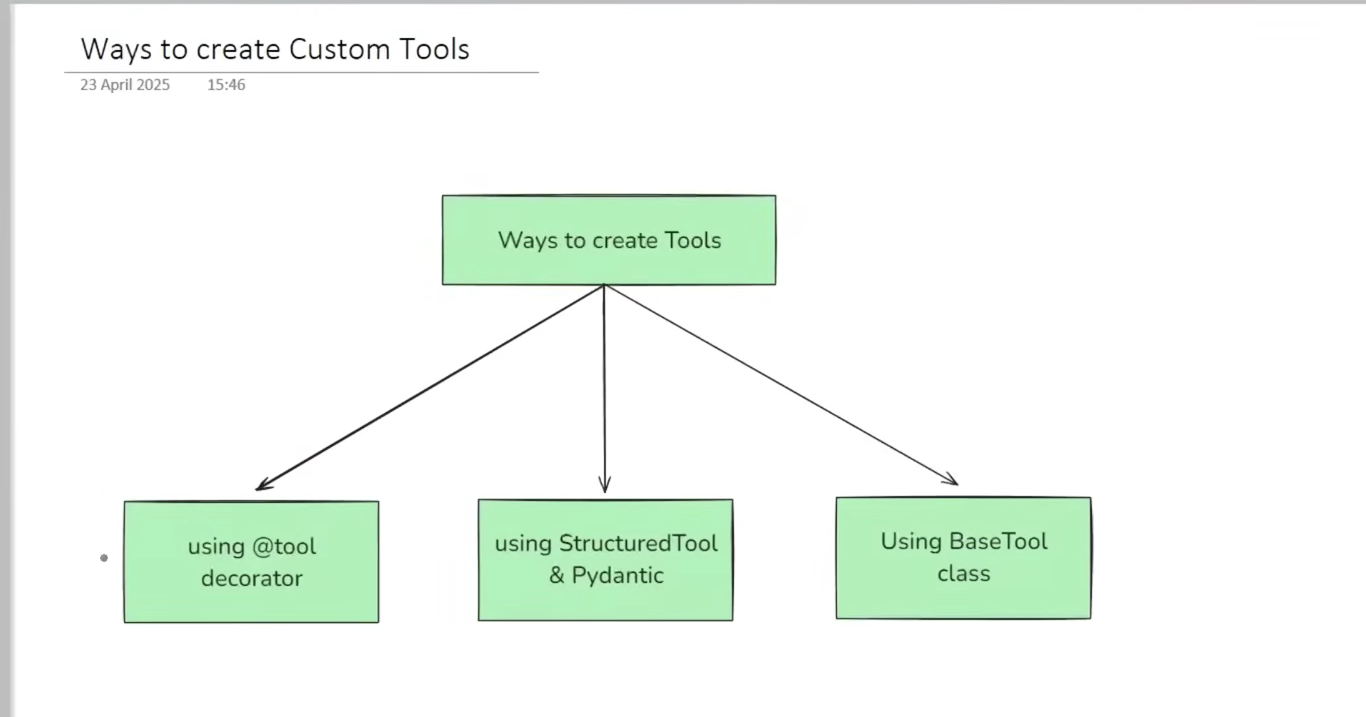

# Tools

## Built in Tools

### DuckDuckGo ,Shell , Mail

In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

result = search.invoke("todays gold rate in kanpur")

print(result)

In [ ]:
from langchain_community.tools import ShellTool

# Initialize the tool
shell = ShellTool()

# Correct way to invoke by passing arguments as a structured dictionary
result = shell.invoke({"commands": ["code ."]})

# Print the system user output
print(result)


### Making Custom Tools

## 1. Using @tool decorator

In [5]:
from langchain_core.tools import tool 

In [9]:
@tool
def multiply (a : int,b : int) -> int:
    "Multiply two numbers"
    return a*b

In [11]:
result = multiply.invoke({"a":5 , "b":10})

In [12]:
result

50

## 2. Structured Tool / Pydantic

In [14]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field



In [19]:
class multiplyInput(BaseModel):
    # Removing 'required=True' works perfectly. 
    # Because there is no default value (like = 0), Pydantic knows these are required.
    a: int = Field(description="first Num")
    b: int = Field(description="Second Num")


In [20]:
def multiply(a,b):
    return a*b

In [21]:
multiply_tool = StructuredTool.from_function(
    func = multiply,
    name = "Multiply",
    description = "This will return multiply of Two Nums",
    args_schema = multiplyInput
)

In [23]:
result = multiply_tool.invoke({"a" : 2,"b":5})

In [24]:
print(result)

10


## 3. BaseTool 
###        All other tool types like @tool, Structured Tool are built on top of BaseTool